
# Final Benchmark — CPU Baseline và GPU V1 → V5


Cấu hình cố định:

- Image: `512×512`
- Patch: `7×7`
- Search window: `21×21`
- CUDA block: `16×16`
- `h = 0.12`

Các phiên bản:

- **CPU baseline** — dense sequential NLM, dùng làm reference.
- **GPU V1** — song song hóa theo output pixel.
- **GPU V2** — Shared Memory tile + halo.
- **GPU V3** — Cross-Correlation accelerated dense NLM.
- **GPU V4** — Adaptive Search + Candidate Preselection, thuộc nhánh approximate/adaptive.
- **GPU V5** — fixed `7×7 / 21×21` specialization kế thừa V2, vẫn là dense exact NLM.


## 1. Benchmark methodology

CPU baseline full $512 \times 512$ đã được chạy trước đó và lưu tại:

```text
outputs/cpu_baseline_512_patch7_search21.npy

In [1]:

from pathlib import Path
import sys
import time
import inspect
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cupy as cp

from skimage import io, color, transform
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("ROOT:", ROOT)
print("CuPy:", cp.__version__)

device_props = cp.cuda.runtime.getDeviceProperties(0)
device_name = device_props["name"]
if isinstance(device_name, bytes):
    device_name = device_name.decode()

print("CUDA device:", device_name)


ROOT: e:\Lap trinh song song ud\gpu_dense_vector_retrieval
CuPy: 14.1.1
CUDA device: NVIDIA GeForce RTX 3050 Laptop GPU


## 2. Import các version và benchmark helpers

In [2]:

from nlm.cpu import nlm_cpu_naive
from nlm.benchmark import benchmark_cuda_kernel, benchmark_gpu_end_to_end

gpu_modules = {
    "V1": importlib.import_module("nlm.gpu_v1"),
    "V2": importlib.import_module("nlm.gpu_v2"),
    "V3": importlib.import_module("nlm.gpu_v3"),
    "V4": importlib.import_module("nlm.gpu_v4"),
    "V5": importlib.import_module("nlm.gpu_v5"),
}

gpu_functions = {
    name: getattr(module, f"nlm_gpu_{name.lower()}")
    for name, module in gpu_modules.items()
}

VERSIONS = ["V1", "V2", "V3", "V4", "V5"]

print("Loaded:", VERSIONS)


Loaded: ['V1', 'V2', 'V3', 'V4', 'V5']


## 3. Cấu hình thí nghiệm

In [3]:

IMAGE_NAME = "02.png"

IMAGE_SIZE = (512, 512)
PATCH_SIZE = 7
SEARCH_WINDOW_SIZE = 21
BLOCK_SIZE = (16, 16)
H = 0.12

NOISE_SIGMA = 0.08
RNG_SEED = 42

# Giữ V3 E2E và compute-only cùng batch configuration.
V3_BATCH_SIZE = 8

# V4 final configuration
V4_PARAMS = dict(
    edge_search_window_size=11,
    texture_variance_threshold=0.0025,
    mean_threshold=0.10,
    variance_ratio_threshold=4.0,
)

# Stable benchmark
BENCHMARK_ROUNDS = 3
PREWARM_RUNS = 15
WARMUP_RUNS = 10
MEASURED_RUNS = 50

# CPU baseline đã đo và lưu trước đó
CPU_OUTPUT_PATH = (
    ROOT
    / "outputs"
    / "cpu_baseline_512_patch7_search21.npy"
)
CPU_RUNTIME_SECONDS = 1097.216

print("Image:", IMAGE_SIZE)
print("Patch:", PATCH_SIZE, "x", PATCH_SIZE)
print("Search:", SEARCH_WINDOW_SIZE, "x", SEARCH_WINDOW_SIZE)
print("Block:", BLOCK_SIZE)
print("h:", H)
print("V3 batch size:", V3_BATCH_SIZE)
print("CPU baseline runtime:", CPU_RUNTIME_SECONDS, "s")


Image: (512, 512)
Patch: 7 x 7
Search: 21 x 21
Block: (16, 16)
h: 0.12
V3 batch size: 8
CPU baseline runtime: 1097.216 s


## 4. Load ảnh và tái tạo noisy input

In [4]:

image_path = ROOT / "data" / "input" / IMAGE_NAME

clean = io.imread(image_path)

if clean.ndim == 3:
    clean = color.rgb2gray(clean)

clean = transform.resize(
    clean,
    IMAGE_SIZE,
    anti_aliasing=True,
).astype(np.float32)

if clean.max() > 1.0:
    clean /= 255.0

rng = np.random.default_rng(RNG_SEED)

noisy = np.clip(
    clean
    + rng.normal(
        0.0,
        NOISE_SIGMA,
        clean.shape,
    ).astype(np.float32),
    0.0,
    1.0,
).astype(np.float32)

print("Clean shape:", clean.shape)
print("Clean range:", float(clean.min()), float(clean.max()))
print("Noisy range:", float(noisy.min()), float(noisy.max()))


Clean shape: (512, 512)
Clean range: 0.06617647409439087 0.9357843399047852
Noisy range: 0.0 1.0


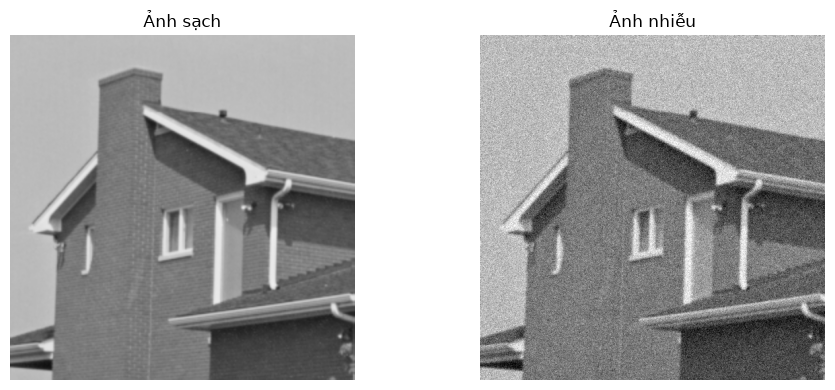

In [5]:

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(clean, cmap="gray", vmin=0, vmax=1)
plt.title("Ảnh sạch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noisy, cmap="gray", vmin=0, vmax=1)
plt.title("Ảnh nhiễu")
plt.axis("off")

plt.tight_layout()
plt.show()



## 5. Helper functions và wrapper thống nhất

`run_gpu()` cố định toàn bộ benchmark configuration.

Đặc biệt, V3 End-to-End cũng được truyền batch size giống phần compute-only để tránh benchmark hai workload/config khác nhau.


In [6]:

def _call_with_supported_kwargs(fn, **kwargs):
    sig = inspect.signature(fn)
    return fn(**{
        k: v
        for k, v in kwargs.items()
        if k in sig.parameters
    })


def run_gpu(version, image):
    kwargs = dict(
        image=image,
        patch_size=PATCH_SIZE,
        search_window_size=SEARCH_WINDOW_SIZE,
        h=H,
        block_size=BLOCK_SIZE,
    )

    if version == "V3":
        kwargs.update(
            batch_size=V3_BATCH_SIZE,
            displacement_batch_size=V3_BATCH_SIZE,
        )

    if version == "V4":
        kwargs.update(V4_PARAMS)

    return _call_with_supported_kwargs(
        gpu_functions[version],
        **kwargs,
    )


def quality_metrics(reference, test):
    return {
        "PSNR (dB)": peak_signal_noise_ratio(
            reference,
            test,
            data_range=1.0,
        ),
        "SSIM": structural_similarity(
            reference,
            test,
            data_range=1.0,
        ),
    }


def diff_stats(reference, candidate):
    diff = np.abs(reference - candidate)
    return {
        "MAE": float(np.mean(diff)),
        "Max error": float(np.max(diff)),
        "allclose": bool(
            np.allclose(
                reference,
                candidate,
                rtol=1e-4,
                atol=1e-4,
            )
        ),
    }



## 6. Load CPU baseline full-size đã lưu




In [7]:

if not CPU_OUTPUT_PATH.exists():
    raise FileNotFoundError(
        "Không tìm thấy CPU baseline đã lưu:\n"
        f"{CPU_OUTPUT_PATH}\n"
        "Hãy kiểm tra lại file outputs/cpu_baseline_512_patch7_search21.npy"
    )

cpu_full = np.load(CPU_OUTPUT_PATH)

if cpu_full.shape != IMAGE_SIZE:
    raise ValueError(
        f"CPU baseline shape {cpu_full.shape} != expected {IMAGE_SIZE}"
    )

print("Loaded CPU baseline:", CPU_OUTPUT_PATH)
print("CPU output shape:", cpu_full.shape)
print("Measured CPU runtime:", f"{CPU_RUNTIME_SECONDS:.3f} s")


Loaded CPU baseline: e:\Lap trinh song song ud\gpu_dense_vector_retrieval\outputs\cpu_baseline_512_patch7_search21.npy
CPU output shape: (512, 512)
Measured CPU runtime: 1097.216 s



## 7. Chạy V1 → V5 để lấy output full-size

Các output này dùng cho:

- correctness;
- PSNR / SSIM;
- visualization.

Đây **không phải** cell benchmark.


In [8]:

gpu_outputs = {}

for version in VERSIONS:
    print("Running", version, "...")
    gpu_outputs[version] = run_gpu(version, noisy)
    cp.cuda.Stream.null.synchronize()

print("Done.")


Running V1 ...
Running V2 ...
Running V3 ...
Running V4 ...
Running V5 ...
Done.



## 8. Correctness toàn ảnh với CPU baseline

Kỳ vọng:

$
CPU \approx V1 \approx V2 \approx V3 \approx V5
$

V4 là adaptive/approximate branch nên `allclose=False` là bình thường.


In [9]:

correctness_rows = []

for version in VERSIONS:
    row = {"Version": version}
    row.update(diff_stats(
        cpu_full,
        gpu_outputs[version],
    ))
    correctness_rows.append(row)

correctness_df = pd.DataFrame(correctness_rows)
display(correctness_df)


,Version,MAE,Max error,allclose
0,V1,1.916083e-07,1.788139e-06,True
1,V2,1.916083e-07,1.788139e-06,True
2,V3,7.215766e-08,6.556511e-07,True
3,V4,7.655561e-03,1.250041e-01,False
4,V5,1.916130e-07,1.788139e-06,True



### Cách đọc correctness

- **V1, V2, V3, V5**: `allclose=True` xác nhận các tối ưu vẫn giữ dense NLM tương đương CPU.
- **V4**: sai khác có chủ đích do Adaptive Search + Candidate Preselection thay đổi candidate set.


## 9. PSNR / SSIM

In [10]:

quality_rows = [
    {
        "Version": "Noisy",
        **quality_metrics(clean, noisy),
    }
]

for version in VERSIONS:
    quality_rows.append({
        "Version": version,
        **quality_metrics(clean, gpu_outputs[version]),
    })

quality_df = pd.DataFrame(quality_rows)
display(quality_df)


,Version,PSNR (dB),SSIM
0,Noisy,21.946645,0.252810
1,V1,33.663911,0.893857
2,V2,33.663911,0.893857
3,V3,33.663911,0.893857
4,V4,35.092371,0.896091
5,V5,33.663911,0.893857



## 10. Chuẩn bị compute-only launchers

`compute-only` dùng các input/buffer đã chuẩn bị trước và đo GPU computation bằng CUDA Events.

Không gọi chung là “single-kernel time” vì V3 và V4 là multi-stage / multi-kernel pipelines.


In [11]:

def _extract_launcher(prepared):
    if callable(prepared):
        return prepared

    if isinstance(prepared, tuple):
        for item in prepared:
            if callable(item):
                return item

    if isinstance(prepared, dict):
        for key in (
            "kernel_launcher",
            "pipeline_launcher",
            "launcher",
        ):
            value = prepared.get(key)
            if callable(value):
                return value

    raise TypeError("Không tìm thấy callable launcher.")


def prepare_compute_launcher(version, image):
    module = gpu_modules[version]

    kwargs = dict(
        image=image,
        patch_size=PATCH_SIZE,
        search_window_size=SEARCH_WINDOW_SIZE,
        h=H,
        block_size=BLOCK_SIZE,
    )

    if version == "V3":
        kwargs.update(
            batch_size=V3_BATCH_SIZE,
            displacement_batch_size=V3_BATCH_SIZE,
        )

    if version == "V4":
        kwargs.update(V4_PARAMS)

    candidate_names = [
        f"prepare_gpu_{version.lower()}_pipeline_launch",
        f"prepare_gpu_{version.lower()}_kernel_launch",
        f"prepare_nlm_gpu_{version.lower()}_launch",
        f"create_gpu_{version.lower()}_pipeline_launcher",
        f"create_gpu_{version.lower()}_kernel_launcher",
    ]

    errors = []

    for name in candidate_names:
        fn = getattr(module, name, None)
        if fn is None:
            continue

        try:
            prepared = _call_with_supported_kwargs(
                fn,
                **kwargs,
            )
            launcher = _extract_launcher(prepared)
            print(version, "launcher:", name)
            return launcher
        except Exception as exc:
            errors.append((name, repr(exc)))

    raise RuntimeError(
        f"Không tìm được compute launcher cho {version}.\n"
        f"Đã thử: {errors}"
    )


compute_launchers = {
    version: prepare_compute_launcher(version, noisy)
    for version in VERSIONS
}

print("All compute launchers prepared.")


V1 launcher: create_gpu_v1_kernel_launcher
V2 launcher: prepare_gpu_v2_kernel_launch
V3 launcher: prepare_gpu_v3_pipeline_launch
V4 launcher: prepare_gpu_v4_pipeline_launch
V5 launcher: prepare_gpu_v5_kernel_launch
All compute launchers prepared.



## 11. Final paired benchmark — 3 rounds/version

Đây là cell benchmark chính.

### Vì sao benchmark theo từng version?

Nếu đo:

```text
E2E V1 → V5
rồi
Compute V1 → V5
```

thì hai phép đo của cùng một version xảy ra ở thời điểm khá xa nhau. GPU laptop có thể thay đổi:

- clock;
- boost state;
- nhiệt độ;
- power state;
- ảnh hưởng từ tiến trình nền.

Ở đây ta benchmark từng version riêng và đảo thứ tự giữa các round:

```text
Round 1: Compute → E2E
Round 2: E2E → Compute
Round 3: Compute → E2E
```

Nhờ đó giảm bias do thứ tự đo.


In [12]:

benchmark_records = []
round_records = []

for version in VERSIONS:
    print("\n" + "=" * 72)
    print("FINAL BENCHMARK:", version)
    print("=" * 72)

    compute_round_medians = []
    e2e_round_medians = []

    for round_idx in range(BENCHMARK_ROUNDS):
        round_no = round_idx + 1
        print(f"\nRound {round_no}/{BENCHMARK_ROUNDS}")

        # Prewarm cả compute path và public E2E path của chính version này.
        for _ in range(PREWARM_RUNS):
            compute_launchers[version]()
        cp.cuda.Stream.null.synchronize()

        for _ in range(PREWARM_RUNS):
            _ = run_gpu(version, noisy)
        cp.cuda.Stream.null.synchronize()

        def measure_compute():
            result = benchmark_cuda_kernel(
                compute_launchers[version],
                warmup_runs=WARMUP_RUNS,
                measured_runs=MEASURED_RUNS,
            )
            return result, float(result["median_ms"])

        def measure_e2e():
            result = benchmark_gpu_end_to_end(
                function=lambda v=version: run_gpu(v, noisy),
                warmup_runs=WARMUP_RUNS,
                measured_runs=MEASURED_RUNS,
            )
            return result, float(result["median_seconds"] * 1000.0)

        # Đảo thứ tự để giảm order bias.
        if round_idx % 2 == 0:
            compute_result, compute_ms = measure_compute()
            cp.cuda.Stream.null.synchronize()

            e2e_result, e2e_ms = measure_e2e()
            cp.cuda.Stream.null.synchronize()

            order = "Compute → E2E"
        else:
            e2e_result, e2e_ms = measure_e2e()
            cp.cuda.Stream.null.synchronize()

            compute_result, compute_ms = measure_compute()
            cp.cuda.Stream.null.synchronize()

            order = "E2E → Compute"

        compute_round_medians.append(compute_ms)
        e2e_round_medians.append(e2e_ms)

        round_records.append({
            "Version": version,
            "Round": round_no,
            "Order": order,
            "Compute median (ms)": compute_ms,
            "E2E median (ms)": e2e_ms,
            "E2E - Compute (ms)": e2e_ms - compute_ms,
        })

        print(
            f"{order}: "
            f"compute={compute_ms:.4f} ms | "
            f"E2E={e2e_ms:.4f} ms"
        )

    final_compute_ms = float(np.median(compute_round_medians))
    final_e2e_ms = float(np.median(e2e_round_medians))

    benchmark_records.append({
        "Version": version,
        "Compute-only (ms)": final_compute_ms,
        "End-to-End (ms)": final_e2e_ms,
        "E2E overhead (ms)": final_e2e_ms - final_compute_ms,
        "Compute round spread (ms)":
            float(np.max(compute_round_medians) - np.min(compute_round_medians)),
        "E2E round spread (ms)":
            float(np.max(e2e_round_medians) - np.min(e2e_round_medians)),
    })

round_df = pd.DataFrame(round_records)
final_benchmark_df = pd.DataFrame(benchmark_records)

print("\nPer-round results:")
display(round_df)

print("\nFinal result = median of 3 round medians:")
display(final_benchmark_df)



FINAL BENCHMARK: V1

Round 1/3
Compute → E2E: compute=24.7409 ms | E2E=26.4365 ms

Round 2/3
E2E → Compute: compute=26.3173 ms | E2E=27.4063 ms

Round 3/3
Compute → E2E: compute=27.0223 ms | E2E=28.3363 ms

FINAL BENCHMARK: V2

Round 1/3
Compute → E2E: compute=25.7725 ms | E2E=27.1128 ms

Round 2/3
E2E → Compute: compute=26.4417 ms | E2E=27.4347 ms

Round 3/3
Compute → E2E: compute=26.4540 ms | E2E=27.7852 ms

FINAL BENCHMARK: V3

Round 1/3
Compute → E2E: compute=20.0453 ms | E2E=21.4287 ms

Round 2/3
E2E → Compute: compute=20.3469 ms | E2E=21.4318 ms

Round 3/3
Compute → E2E: compute=20.3494 ms | E2E=21.6960 ms

FINAL BENCHMARK: V4

Round 1/3
Compute → E2E: compute=8.9651 ms | E2E=10.0923 ms

Round 2/3
E2E → Compute: compute=9.1223 ms | E2E=10.0502 ms

Round 3/3
Compute → E2E: compute=9.1126 ms | E2E=9.9859 ms

FINAL BENCHMARK: V5

Round 1/3
Compute → E2E: compute=13.4124 ms | E2E=14.5168 ms

Round 2/3
E2E → Compute: compute=13.4436 ms | E2E=14.5410 ms

Round 3/3
Compute → E2E: compu

,Version,Round,Order,Compute median (ms),E2E median (ms),E2E - Compute (ms)
0,V1,1,Compute → E2E,24.740864,26.43650,1.695636
1,V1,2,E2E → Compute,26.317311,27.40625,1.088939
2,V1,3,Compute → E2E,27.022336,28.33630,1.313964
3,V2,1,Compute → E2E,25.772544,27.11280,1.340256
4,V2,2,E2E → Compute,26.441729,27.43470,0.992971
5,V2,3,Compute → E2E,26.454016,27.78520,1.331184
6,V3,1,Compute → E2E,20.045312,21.42865,1.383338
7,V3,2,E2E → Compute,20.346880,21.43185,1.084970
8,V3,3,Compute → E2E,20.349441,21.69600,1.346559
9,V4,1,Compute → E2E,8.965120,10.09230,1.127180



Final result = median of 3 round medians:


,Version,Compute-only (ms),End-to-End (ms),E2E overhead (ms),Compute round spread (ms),E2E round spread (ms)
0,V1,26.317311,27.40625,1.088939,2.281472,1.89980
1,V2,26.441729,27.43470,0.992971,0.681472,0.67240
2,V3,20.346880,21.43185,1.084970,0.304129,0.26735
3,V4,9.112576,10.05025,0.937674,0.157184,0.10645
4,V5,13.432832,14.51675,1.083918,0.031232,0.09090


## 12. Timing sanity check

Về mặt pipeline:

$$T_{\text{E2E}} = T_{\text{preparation}} + T_{\text{H2D}} + T_{\text{GPU}} + T_{\text{D2H}} + \dots$$

nên về trực giác ta kỳ vọng $\text{End-to-End} \ge \text{compute-only}$.

Tuy nhiên hai metric được đo bằng hai cơ chế khác nhau và ở các lần chạy riêng biệt, nên chênh lệch rất nhỏ quanh $0$ vẫn có thể là measurement noise.



In [13]:

timing_check_df = final_benchmark_df[
    [
        "Version",
        "Compute-only (ms)",
        "End-to-End (ms)",
        "E2E overhead (ms)",
    ]
].copy()

TIMING_TOLERANCE_MS = 0.5

timing_check_df["Timing check"] = np.where(
    timing_check_df["E2E overhead (ms)"] >= -TIMING_TOLERANCE_MS,
    "OK",
    "RECHECK",
)

display(timing_check_df)

if (timing_check_df["Timing check"] == "RECHECK").any():
    print(
        "Có version E2E thấp hơn compute-only quá tolerance. "
        "Nên chạy lại cell benchmark trước khi chốt số final."
    )
else:
    print(
        "Timing consistency acceptable "
        f"(tolerance = {TIMING_TOLERANCE_MS} ms)."
    )


,Version,Compute-only (ms),End-to-End (ms),E2E overhead (ms),Timing check
0,V1,26.317311,27.40625,1.088939,OK
1,V2,26.441729,27.43470,0.992971,OK
2,V3,20.346880,21.43185,1.084970,OK
3,V4,9.112576,10.05025,0.937674,OK
4,V5,13.432832,14.51675,1.083918,OK


Timing consistency acceptable (tolerance = 0.5 ms).



## 13. Bảng tổng hợp cuối cùng

Bảng này ghép:

- runtime final;
- image quality;
- correctness status;
- CPU speedup.

**Speedup hệ thống chính** được tính bằng End-to-End GPU so với CPU baseline.


In [14]:

summary_rows = []

cpu_ms = CPU_RUNTIME_SECONDS * 1000.0

for version in VERSIONS:
    bench_row = final_benchmark_df[
        final_benchmark_df["Version"] == version
    ].iloc[0]

    q = quality_metrics(
        clean,
        gpu_outputs[version],
    )

    c = correctness_df[
        correctness_df["Version"] == version
    ].iloc[0]

    summary_rows.append({
        "Version": version,
        "Compute-only (ms)": bench_row["Compute-only (ms)"],
        "End-to-End (ms)": bench_row["End-to-End (ms)"],
        "PSNR (dB)": q["PSNR (dB)"],
        "SSIM": q["SSIM"],
        "MAE vs CPU": c["MAE"],
        "allclose CPU": c["allclose"],
        "E2E speedup vs CPU":
            cpu_ms / bench_row["End-to-End (ms)"],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,Version,Compute-only (ms),End-to-End (ms),PSNR (dB),SSIM,MAE vs CPU,allclose CPU,E2E speedup vs CPU
0,V1,26.317311,27.40625,33.663911,0.893857,1.916083e-07,True,40035.247419
1,V2,26.441729,27.43470,33.663911,0.893857,1.916083e-07,True,39993.730555
2,V3,20.346880,21.43185,33.663911,0.893857,7.215766e-08,True,51195.580426
3,V4,9.112576,10.05025,35.092371,0.896091,7.655561e-03,False,109173.005657
4,V5,13.432832,14.51675,33.663911,0.893857,1.916130e-07,True,75582.757766



## 14. Speedup giữa các GPU version

- `vs V1`: thể hiện progression từ CUDA baseline.
- `vs V3`: làm rõ lợi ích của V4 và V5 so với Cross-Correlation version.


In [15]:

v1 = summary_df[summary_df["Version"] == "V1"].iloc[0]
v3 = summary_df[summary_df["Version"] == "V3"].iloc[0]

speedup_rows = []

for _, row in summary_df.iterrows():
    speedup_rows.append({
        "Version": row["Version"],
        "Compute speedup vs V1":
            v1["Compute-only (ms)"] / row["Compute-only (ms)"],
        "E2E speedup vs V1":
            v1["End-to-End (ms)"] / row["End-to-End (ms)"],
        "Compute speedup vs V3":
            v3["Compute-only (ms)"] / row["Compute-only (ms)"],
        "E2E speedup vs V3":
            v3["End-to-End (ms)"] / row["End-to-End (ms)"],
        "E2E speedup vs CPU":
            row["E2E speedup vs CPU"],
    })

speedup_df = pd.DataFrame(speedup_rows)
display(speedup_df)


,Version,Compute speedup vs V1,E2E speedup vs V1,Compute speedup vs V3,E2E speedup vs V3,E2E speedup vs CPU
0,V1,1.000000,1.000000,0.773137,0.782006,40035.247419
1,V2,0.995295,0.998963,0.769499,0.781195,39993.730555
2,V3,1.293432,1.278763,1.000000,1.000000,51195.580426
3,V4,2.888021,2.726922,2.232835,2.132469,109173.005657
4,V5,1.959178,1.887905,1.514713,1.476353,75582.757766


## 15. Biểu đồ runtime cuối cùng

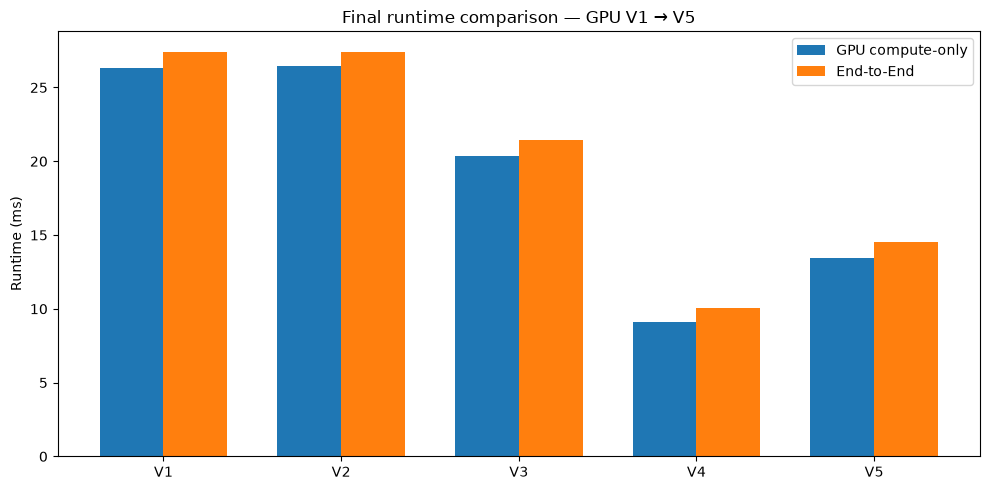

In [16]:

x = np.arange(len(VERSIONS))
width = 0.36

compute_values = [
    float(
        summary_df.loc[
            summary_df["Version"] == v,
            "Compute-only (ms)",
        ].iloc[0]
    )
    for v in VERSIONS
]

e2e_values = [
    float(
        summary_df.loc[
            summary_df["Version"] == v,
            "End-to-End (ms)",
        ].iloc[0]
    )
    for v in VERSIONS
]

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    compute_values,
    width,
    label="GPU compute-only",
)

plt.bar(
    x + width / 2,
    e2e_values,
    width,
    label="End-to-End",
)

plt.xticks(x, VERSIONS)
plt.ylabel("Runtime (ms)")
plt.title("Final runtime comparison — GPU V1 → V5")
plt.legend()
plt.tight_layout()
plt.show()


## 16. Biểu đồ speedup End-to-End so với CPU

CPU baseline:

$$T_{\text{CPU}} = 1097.216\text{ s} = 1{,}097{,}216\text{ ms}$$

Speedup:

$$S_i = \frac{T_{\text{CPU}}}{T_{\text{GPU}, i}^{\text{E2E}}}$$

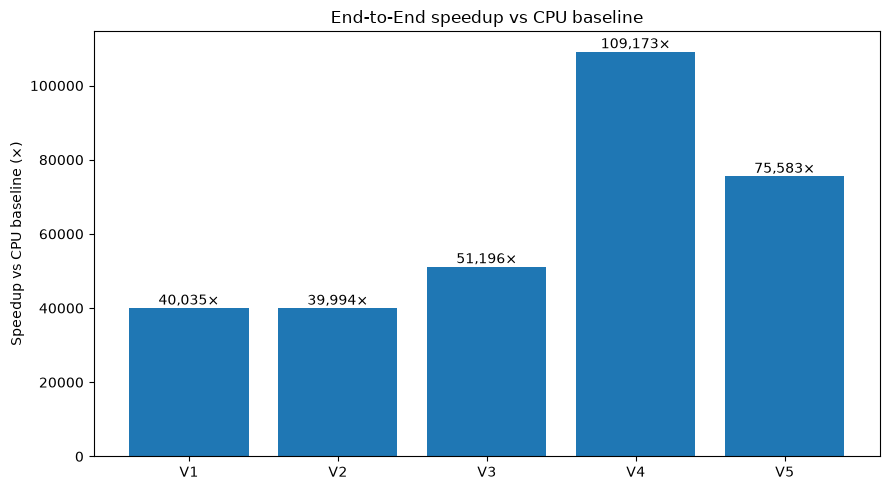

In [17]:

plt.figure(figsize=(9, 5))

plt.bar(
    summary_df["Version"],
    summary_df["E2E speedup vs CPU"],
)

plt.ylabel("Speedup vs CPU baseline (×)")
plt.title("End-to-End speedup vs CPU baseline")

for i, value in enumerate(summary_df["E2E speedup vs CPU"]):
    plt.text(
        i,
        value,
        f"{value:,.0f}×",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()
